In [46]:
#Packages
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.bk_filter import bkfilter
from statsmodels.tsa.filters.cf_filter import cffilter
from statsmodels.tsa.filters.hp_filter import hpfilter
from scipy.signal import butter, filtfilt
from statsmodels.tsa.statespace.structural import UnobservedComponents


In [47]:
file_path = pathlib.Path("../data/processed/PIB_USA.xlsx")
print(f"Usando: {file_path.resolve()}")


Usando: /Users/santi/Documents/EAFIT/Coyuntura/scraping-NAIRU/data/processed/PIB_USA.xlsx


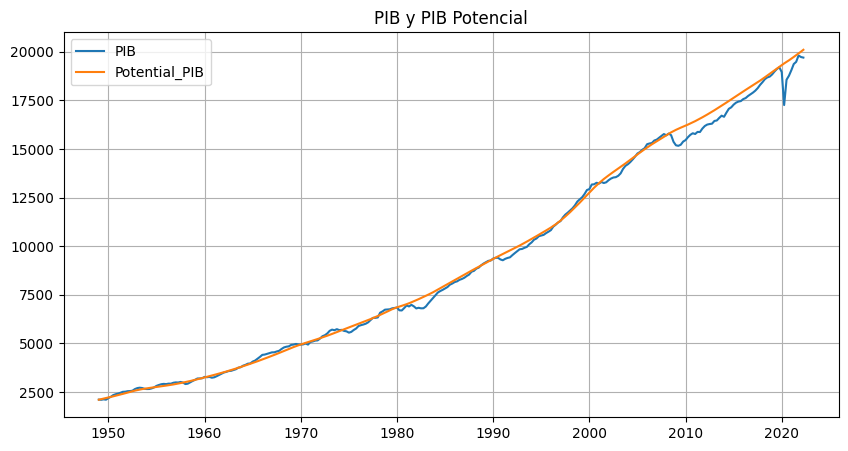

In [48]:
# Load Excel file
df = pd.read_excel(file_path)

df = df.rename(columns={
    "Value(Billions)": "PIB",
    "Potential Value(Billions)": "Potential_PIB"
})

df["t"] = pd.PeriodIndex.from_fields(
    year=df["Year"],
    quarter=df["Quarter"],
    freq="Q"
)
df = df.sort_values("t").set_index("t")

# Variation = t/t_-1 - 1 (crecimiento trimestral del PIB real)
df["Variation"] = df["PIB"] / df["PIB"].shift(1) - 1

df_plot = df.copy()
df_plot.index = df_plot.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(df_plot.index, df_plot["PIB"], label="PIB")
plt.plot(df_plot.index, df_plot["Potential_PIB"], label="Potential_PIB")
plt.title("PIB y PIB Potencial")
plt.legend()
plt.grid(True)
plt.show()


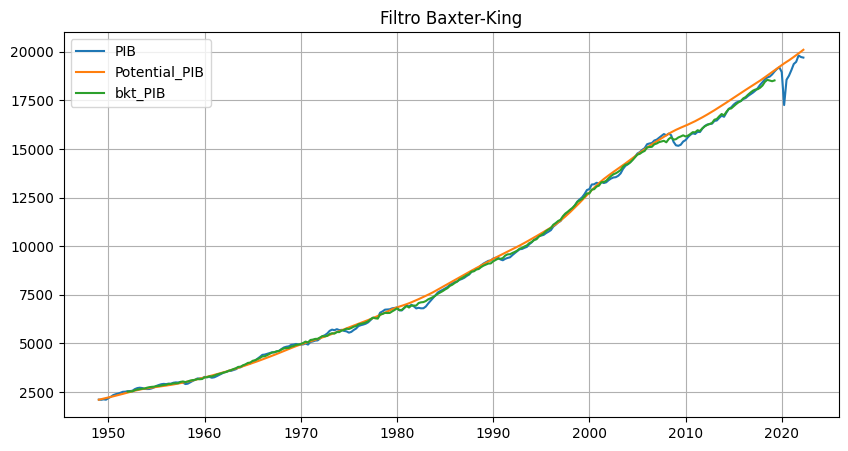

In [49]:
#Baxter and King Filter
bk_cycle = bkfilter(df["PIB"], low=6, high=32, K=12)
df["bk_PIB"] = bk_cycle
df["bkt_PIB"] = df["PIB"] - df["bk_PIB"]

df_bk_plot = df.copy()
df_bk_plot.index = df_bk_plot.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(df_bk_plot.index, df_bk_plot["PIB"], label="PIB")
plt.plot(df_bk_plot.index, df_bk_plot["Potential_PIB"], label="Potential_PIB")
plt.plot(df_bk_plot.index, df_bk_plot["bkt_PIB"], label="bkt_PIB")
plt.title("Filtro Baxter-King")
plt.legend()
plt.grid(True)
plt.show()

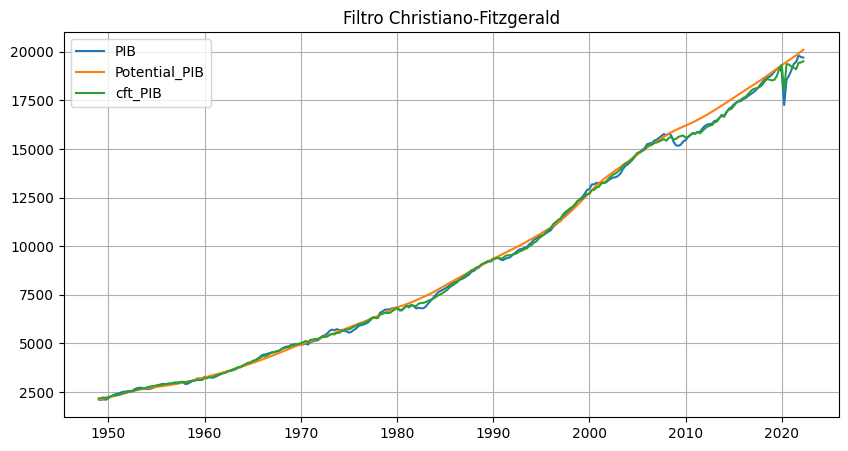

In [50]:
#Christiano and Fitzgerald Filter
cf_cycle, cf_trend = cffilter(df["PIB"], low=6, high=32, drift=False)
df["cf_PIB"] = cf_cycle
df["cft_PIB"] = cf_trend

df_cf_plot = df.copy()
df_cf_plot.index = df_cf_plot.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(df_cf_plot.index, df_cf_plot["PIB"], label="PIB")
plt.plot(df_cf_plot.index, df_cf_plot["Potential_PIB"], label="Potential_PIB")
plt.plot(df_cf_plot.index, df_cf_plot["cft_PIB"], label="cft_PIB")
plt.title("Filtro Christiano-Fitzgerald")
plt.legend()
plt.grid(True)
plt.show()


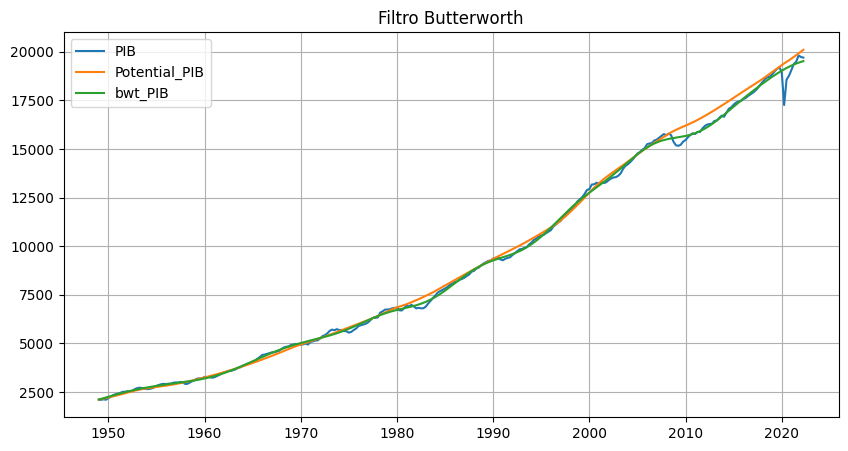

In [51]:
#Butterworth Filter
cutoff = 1 / 16
b, a = butter(N=8, Wn=cutoff, btype="low")
df["bwt_PIB"] = filtfilt(b, a, df["PIB"].astype(float))
df["bw_PIB"] = df["PIB"] - df["bwt_PIB"]

df_bw_plot = df.copy()
df_bw_plot.index = df_bw_plot.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(df_bw_plot.index, df_bw_plot["PIB"], label="PIB")
plt.plot(df_bw_plot.index, df_bw_plot["Potential_PIB"], label="Potential_PIB")
plt.plot(df_bw_plot.index, df_bw_plot["bwt_PIB"], label="bwt_PIB")
plt.title("Filtro Butterworth")
plt.legend()
plt.grid(True)
plt.show()


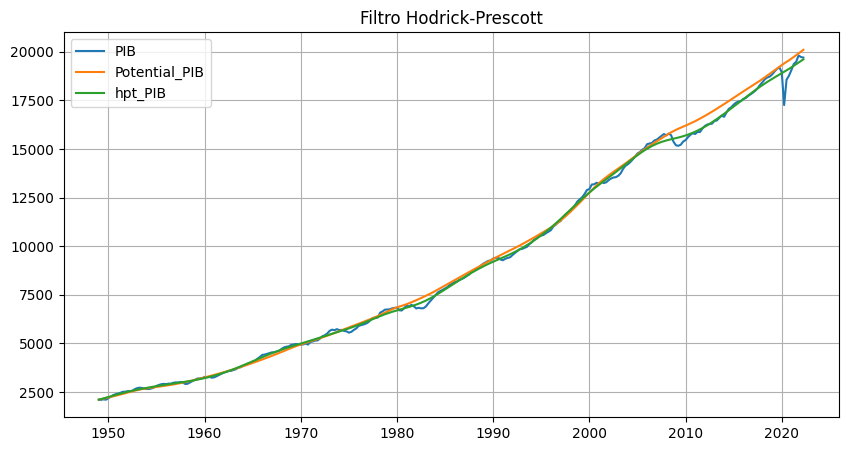

In [52]:
#Hodrick-Prescott Filter
hp_cycle, hp_trend = hpfilter(df["PIB"], lamb=1600)
df["hp_PIB"] = hp_cycle
df["hpt_PIB"] = hp_trend

df_hp_plot = df.copy()
df_hp_plot.index = df_hp_plot.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(df_hp_plot.index, df_hp_plot["PIB"], label="PIB")
plt.plot(df_hp_plot.index, df_hp_plot["Potential_PIB"], label="Potential_PIB")
plt.plot(df_hp_plot.index, df_hp_plot["hpt_PIB"], label="hpt_PIB")
plt.title("Filtro Hodrick-Prescott")
plt.legend()
plt.grid(True)
plt.show()

/Users/santi/Documents/EAFIT/Coyuntura/scraping-NAIRU/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/structural.py:1030: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-unconstrained[offset]))
/Users/santi/Documents/EAFIT/Coyuntura/scraping-NAIRU/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/structural.py:1037: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-unconstrained[offset]))


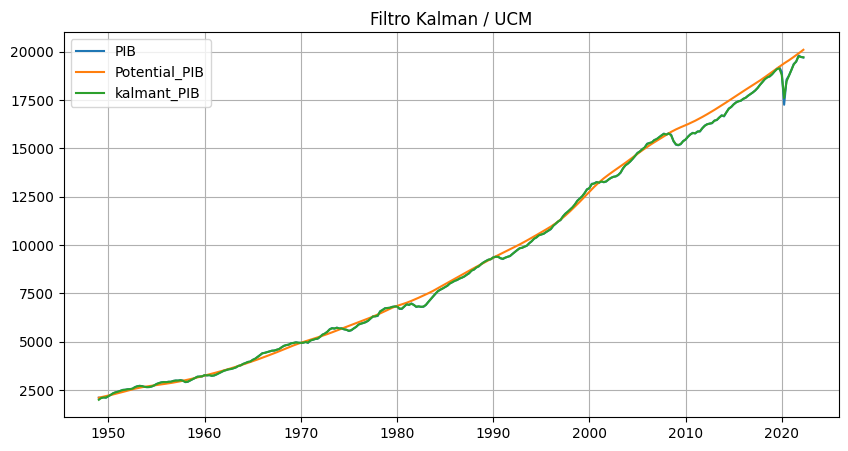

In [53]:
#Kalman Filter
ucm_model = UnobservedComponents(
    endog=df["PIB"],
    level="random walk with drift",
    #drift=True,
    cycle=True,
    damped_cycle=True,
    stochastic_cycle=True,
    cycle_period_bounds=[0.3,40]
)

ucm_result = ucm_model.fit(disp=False)

# Tendencia estimada
df["kalmant_PIB"] = ucm_result.level.smoothed

# Ciclo estimado
# Dependiendo de la versión de statsmodels, esto puede variar.
# Normalmente:
if hasattr(ucm_result, "cycle") and hasattr(ucm_result.cycle, "smoothed"):
    #df["kalman_PIB"] = ucm_result.cycle.smoothed
    df["kalman_PIB"] = df["PIB"] - df["kalmant_PIB"]
else:
    # fallback si la estructura interna cambia
    df["kalman_PIB"] = df["PIB"] - df["kalmant_PIB"]

df_kalman_plot = df.copy()
df_kalman_plot.index = df_kalman_plot.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(df_kalman_plot.index, df_kalman_plot["PIB"], label="PIB")
plt.plot(df_kalman_plot.index, df_kalman_plot["Potential_PIB"], label="Potential_PIB")
plt.plot(df_kalman_plot.index, df_kalman_plot["kalmant_PIB"], label="kalmant_PIB")
plt.title("Filtro Kalman / UCM")
plt.legend()
plt.grid(True)
plt.show()

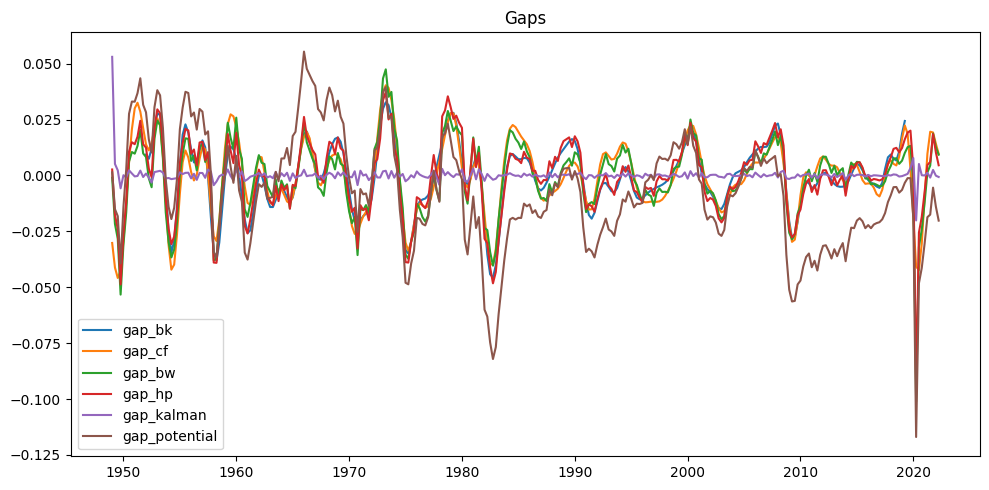

In [54]:
# ====================
# Creación logaritmos
# ====================
vars_to_log = ["PIB", "Potential_PIB", "bkt_PIB", "cft_PIB", "bwt_PIB", "hpt_PIB", "kalmant_PIB"]

for var in vars_to_log:
    df[f"ln{var}"] = np.log(df[var])


# =====
# GAPS
# =====
df["gap_bk"] = df["lnPIB"] - df["lnbkt_PIB"]
df["gap_cf"] = df["lnPIB"] - df["lncft_PIB"]
df["gap_bw"] = df["lnPIB"] - df["lnbwt_PIB"]
df["gap_hp"] = df["lnPIB"] - df["lnhpt_PIB"]
df["gap_kalman"] = df["lnPIB"] - df["lnkalmant_PIB"]
df["gap_potential"] = df["lnPIB"] - df["lnPotential_PIB"]

plt.figure(figsize=(10, 5))
plt.plot(df.index.to_timestamp(), df["gap_bk"], label="gap_bk")
plt.plot(df.index.to_timestamp(), df["gap_cf"], label="gap_cf")
plt.plot(df.index.to_timestamp(), df["gap_bw"], label="gap_bw")
plt.plot(df.index.to_timestamp(), df["gap_hp"], label="gap_hp")
plt.plot(df.index.to_timestamp(), df["gap_kalman"], label="gap_kalman")
plt.plot(df.index.to_timestamp(), df["gap_potential"], label="gap_potential")
plt.title("Gaps")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# ======================
# Medidas de output gap
# ======================
gap_vars = ["bk", "cf", "bw", "hp", "kalman", "potential"]

for var in gap_vars:
    df[f"abs_gap_{var}"] = df[f"gap_{var}"].abs()

    # egen rev_var = sum(abs_gap_var)
    # In Stata this is cumulative sum
    df[f"rev_{var}"] = df[f"abs_gap_{var}"].cumsum()

    # replace rev_var = rev_var / 269
    df[f"rev_{var}"] = df[f"rev_{var}"] / 269

    df[f"inv_rev_{var}"] = 1 / df[f"rev_{var}"]

# egen rev_total = rowtotal(...)
df["rev_total"] = df[[f"rev_{v}" for v in gap_vars]].sum(axis=1)
df["inv_rev_total"] = df[[f"inv_rev_{v}" for v in gap_vars]].sum(axis=1)

for var in gap_vars:
    df[f"weight_rev_{var}"] = df[f"rev_{var}"] / df["rev_total"]
    df[f"weight_inv_rev_{var}"] = df[f"inv_rev_{var}"] / df["inv_rev_total"]


# weighted potentials
df["weighted_rev_potential"] = (
    df["weight_rev_bk"] * df["lnbkt_PIB"]
    + df["weight_rev_cf"] * df["lncft_PIB"]
    + df["weight_rev_bw"] * df["lnbwt_PIB"]
    + df["weight_rev_hp"] * df["lnhpt_PIB"]
    + df["weight_rev_kalman"] * df["lnkalmant_PIB"]
    + df["weight_rev_potential"] * df["lnPotential_PIB"]
)

df["weighted_inv_rev_potential"] = (
    df["weight_inv_rev_bk"] * df["lnbkt_PIB"]
    + df["weight_inv_rev_cf"] * df["lncft_PIB"]
    + df["weight_inv_rev_bw"] * df["lnbwt_PIB"]
    + df["weight_inv_rev_hp"] * df["lnhpt_PIB"]
    + df["weight_inv_rev_kalman"] * df["lnkalmant_PIB"]
    + df["weight_inv_rev_potential"] * df["lnPotential_PIB"]
)

df["weighted_rev_gap"] = df["lnPIB"] - df["weighted_rev_potential"]
df["weighted_inv_rev_gap"] = df["lnPIB"] - df["weighted_inv_rev_potential"]

**Gráficas**

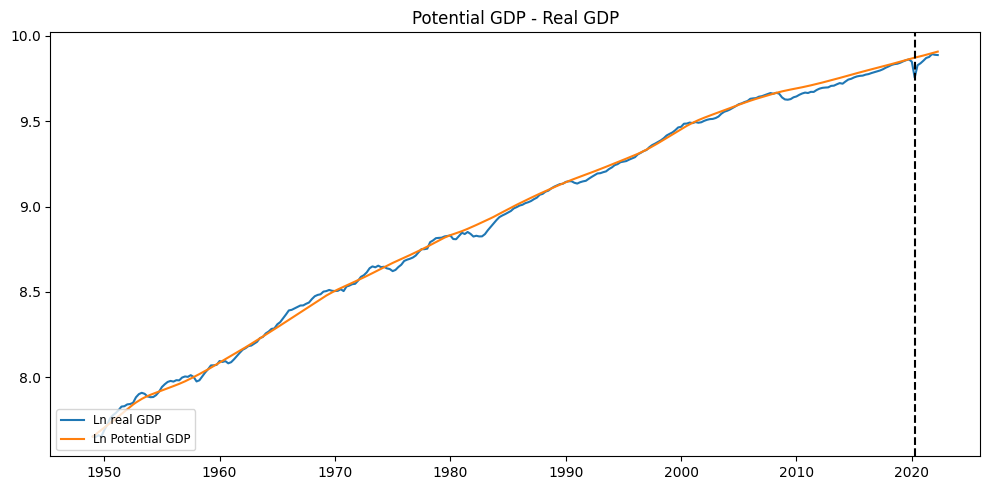

In [56]:
# Convert quarterly index to timestamps
x = df.index.to_timestamp()

# Vertical line at 2020q2
tline_date = pd.Period("2020Q2", freq="Q").to_timestamp()


# ============================
# PIB real vs PIB potencial
# ============================
plt.figure(figsize=(10, 5))
plt.plot(x, df["lnPIB"], label="Ln real GDP")
plt.plot(x, df["lnPotential_PIB"], label="Ln Potential GDP")
plt.axvline(tline_date, linestyle="--", color="black")

plt.title("Potential GDP - Real GDP")
plt.xlabel("")
plt.legend(loc="lower left", fontsize="small")
plt.grid(False)

plt.tight_layout()
plt.show()

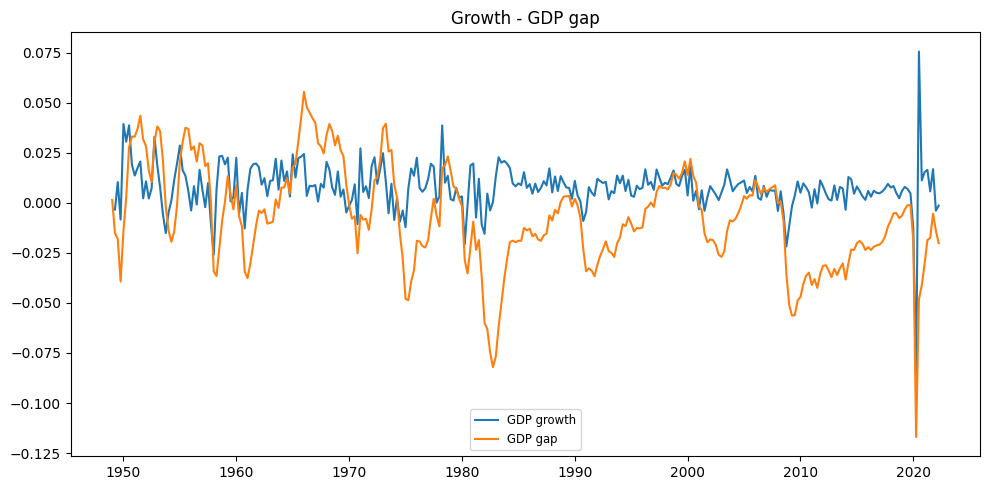

In [62]:
# ============================
# Crecimiento vs Ciclo
# ============================
plt.figure(figsize=(10, 5))
plt.plot(x, df["Variation"], label="GDP growth")
plt.plot(x, df["gap_potential"], label="GDP gap")

plt.title("Growth - GDP gap")
plt.xlabel("")
plt.legend(loc="lower center", fontsize="small")
plt.grid(False)

plt.tight_layout()
plt.show()

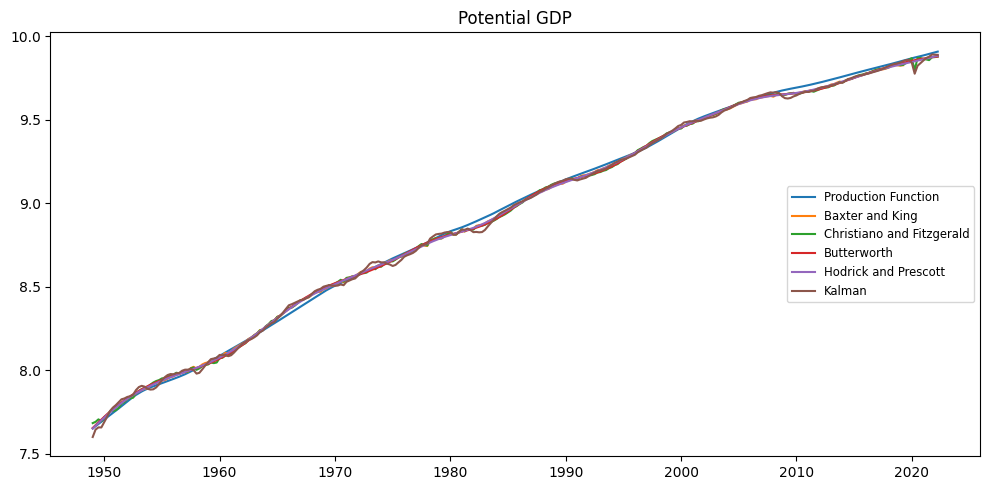

In [58]:
# ===================================
# PIB potencial por cada filtro
# ===================================
plt.figure(figsize=(10, 5))
plt.plot(x, df["lnPotential_PIB"], label="Production Function")
plt.plot(x, df["lnbkt_PIB"], label="Baxter and King")
plt.plot(x, df["lncft_PIB"], label="Christiano and Fitzgerald")
plt.plot(x, df["lnbwt_PIB"], label="Butterworth")
plt.plot(x, df["lnhpt_PIB"], label="Hodrick and Prescott")
plt.plot(x, df["lnkalmant_PIB"], label="Kalman")

plt.title("Potential GDP")
plt.xlabel("")
plt.legend(loc="center right", fontsize="small")
plt.grid(False)

plt.tight_layout()
plt.show()

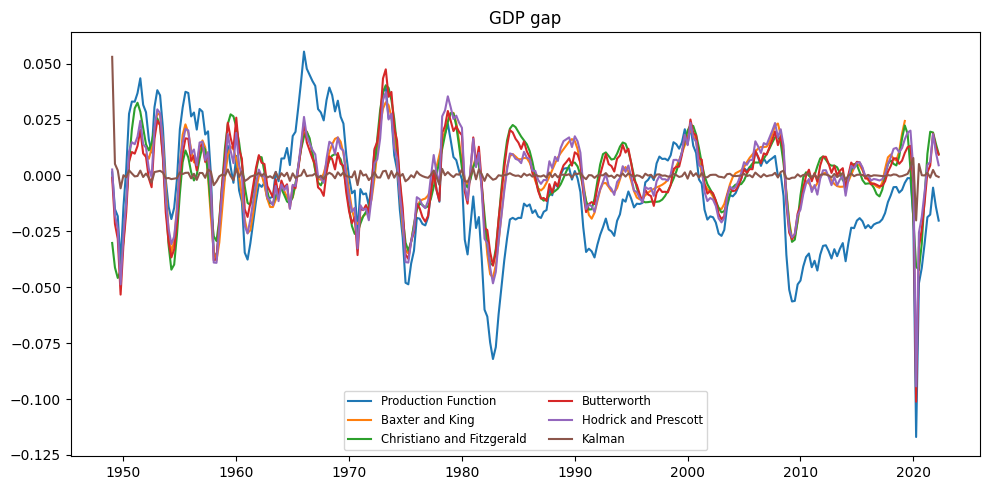

In [59]:
# ===================================
# Brecha del producto por cada filtro
# ===================================
plt.figure(figsize=(10, 5))
plt.plot(x, df["gap_potential"], label="Production Function")
plt.plot(x, df["gap_bk"], label="Baxter and King")
plt.plot(x, df["gap_cf"], label="Christiano and Fitzgerald")
plt.plot(x, df["gap_bw"], label="Butterworth")
plt.plot(x, df["gap_hp"], label="Hodrick and Prescott")
plt.plot(x, df["gap_kalman"], label="Kalman")

plt.title("GDP gap")
plt.xlabel("")
plt.legend(loc="lower center", ncol=2, fontsize="small")
plt.grid(False)

plt.tight_layout()
plt.show()

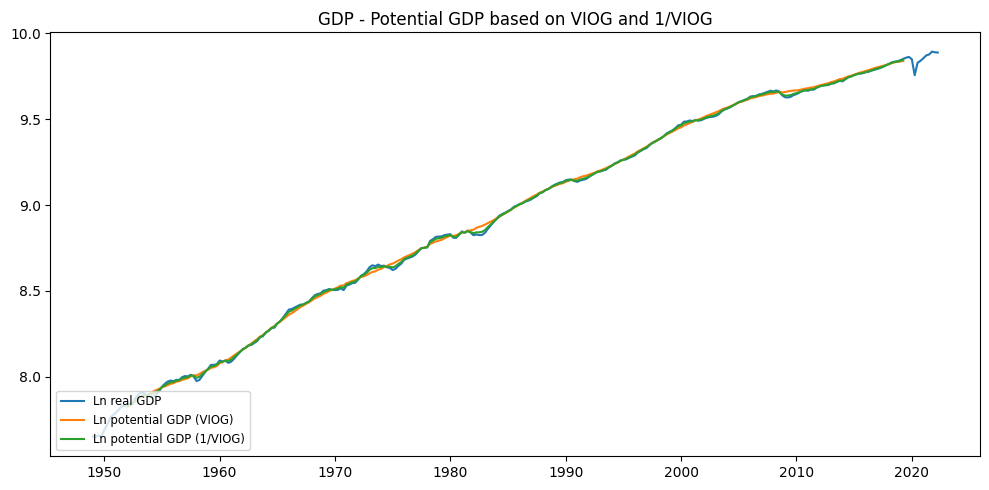

In [60]:
# ===============================================
# PIB potencial con los dos ponderadores y el PIB
# ===============================================
plt.figure(figsize=(10, 5))
plt.plot(x, df["lnPIB"], label="Ln real GDP")
plt.plot(x, df["weighted_rev_potential"], label="Ln potential GDP (VIOG)")
plt.plot(x, df["weighted_inv_rev_potential"], label="Ln potential GDP (1/VIOG)")

plt.title("GDP - Potential GDP based on VIOG and 1/VIOG")
plt.xlabel("")
plt.legend(loc="lower left", fontsize="small")
plt.grid(False)

plt.tight_layout()
plt.show()

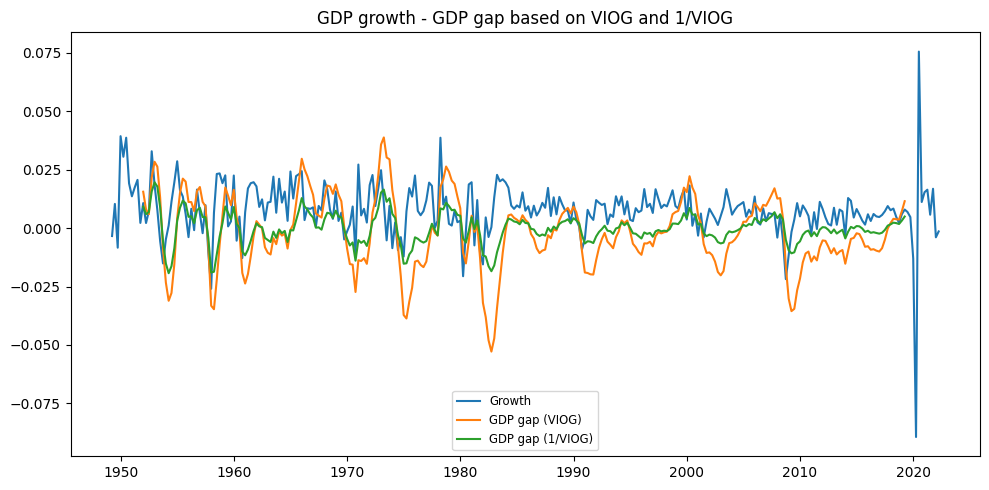

In [61]:
# ==========================================================
# Brecha del PIB potencial por VIOG y 1/VIOG y el crecimiento
# ==========================================================
plt.figure(figsize=(10, 5))
plt.plot(x, df["Variation"], label="Growth")
plt.plot(x, df["weighted_rev_gap"], label="GDP gap (VIOG)")
plt.plot(x, df["weighted_inv_rev_gap"], label="GDP gap (1/VIOG)")

plt.title("GDP growth - GDP gap based on VIOG and 1/VIOG")
plt.xlabel("")
plt.legend(loc="lower center", fontsize="small")
plt.grid(False)

plt.tight_layout()
plt.show()